In [81]:
#Função que obtem dados de um periodo de tempo

In [17]:
#Importações
import yfinance as yf
from datetime import datetime
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pickle

from sklearn.metrics import precision_score
from sklearn import svm

In [18]:
#Funções
def SalvarCsvYF(codigo_empresa, datainicial, datafinal, nomearquivo)->bool:
    try:
        dados = yf.Ticker(codigo_empresa)
        #dat.info
        d1 = datetime.strptime(datainicial,"%d/%m/%Y")
        d2 = datetime.strptime(datafinal,"%d/%m/%Y")
        objeto = dados.history(start = d1 , end = d2)
        objeto.to_json(nomearquivo)
        return True
    except Exception as e:
        print(e)
        return False

In [19]:
class Empresa:
    def __init__(self, nome ):
        self.nome = nome
        self.listaCSV = {}
        self.listaCSVTreinamento={}
        self.acumulodeanos = 0
        self.ano_teste = 0
        self.acuracy = -1
    def addArquivoCSV(self, arquivocsv): # já admiti que vai os dados na ordem 2020, 2020-2021, 2020-2022[..]
        self.ano_teste += 1
        self.listaCSV[self.ano_teste] = arquivocsv
    def addArquivoCSVTreinamento(self, arquivocsv): # já admiti que vai os dados na ordem 2020, 2020-2021, 2020-2022[..]
        self.acumulodeanos += 1
        self.listaCSVTreinamento[self.acumulodeanos] = arquivocsv
    def keys(self):
        return self.listaCSV.keys()
    def obterNumeroCSV(self):
        self.acumulodeanos
    def obterIndex(self, index):
        return self.listaCSV[index]
    def obterIndexTreinamento(self, index):
        return self.listaCSVTreinamento[index]
    

In [20]:
#empresas = ["BBAS3.SA","ITSA4.SA", "BPAC11.SA", "ITUB4.SA", "SANB11.SA"]
empresas = ["BBAS3.SA"]
anos = [ 2019 , 2020, 2021, 2022, 2023, 2024 ]
listaEmpresa = []

for empresa in empresas:
    novaempresa = Empresa(empresa)
    #Dados treinamento
    for ano in anos[:-1]:
        if anos[0] == ano:
            arquivocsv = empresa+"_"+str(ano) + "_Treino.json"
        if anos[0] != ano:
            arquivocsv =  empresa+"_"+str(anos[0])+"-"+ str(ano) + "_Treino.json"
        if not os.path.exists(arquivocsv):
            SalvarCsvYF(empresa, "01/01/"+str(anos[0]) , "31/12/"+str(ano), arquivocsv)
        novaempresa.addArquivoCSVTreinamento(arquivocsv)
    for ano in anos[1:]:
        arquivocsv = empresa+"_"+str(ano) + "_Teste.json"
        if not os.path.exists(arquivocsv):
            SalvarCsvYF(empresa, "01/01/"+str(anos[0]) , "31/12/"+str(ano), arquivocsv)
        novaempresa.addArquivoCSV(arquivocsv)    
    listaEmpresa.append(novaempresa)



In [21]:
def ObterAcuraciaModelForestClassifier(arquivo):
    historico = pd.read_json(arquivo)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = historico[["Close"]]
    data = data.rename(columns = {'Close':'Actual_Close'})
    data["Target"] = historico.rolling(2).apply(lambda x: x.iloc[1] > x.iloc[0])["Close"]
    data.head()
    prehist = historico.copy()
    prehist = prehist.shift(1)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = data.join(prehist[cabecalho]).iloc[1:]
    model = RandomForestClassifier(n_estimators=100, min_samples_split=200, random_state=1)
    data2 = data["Target"]
    train =data.iloc[:-100]
    test = data.iloc[-100:]
    model.fit(train[cabecalho], train["Target"])
    predicao = model.predict( test[cabecalho])
    predicao = pd.Series(predicao,index=test.index)
    accuracy = precision_score( test["Target"], predicao)
    return accuracy, model
    

In [22]:
def ObterAcuraciaModelSVM(arquivo):
    historico = pd.read_json(arquivo)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = historico[["Close"]]
    data = data.rename(columns = {'Close':'Actual_Close'})
    data["Target"] = historico.rolling(2).apply(lambda x: x.iloc[1] > x.iloc[0])["Close"]
    #print(data["Target"])
    #data.head()
    
    prehist = historico.copy()
    prehist = prehist.shift(1)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = data.join(prehist[cabecalho]).iloc[1:]
    model = svm.SVC()
    train = data.iloc[:-100]
    test = data.iloc[-100:]
    model = model.fit(train[cabecalho], train["Target"])
    predicao = model.predict( test[cabecalho])
    predicao = pd.Series(predicao,index=test.index)
    #predicao.plot.line(y="Close", use_index=True)
    accuracy = precision_score( test["Target"], predicao)
    return accuracy, model
    

In [62]:
def TestaModelo( modelo, arquivo):
    historico = pd.read_json(arquivo)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = historico[["Close"]]
    data = data.rename(columns = {'Close':'Actual_Close'})
    data["Target"] = historico.rolling(2).apply(lambda x: x.iloc[1] > x.iloc[0])["Close"]
    
    
    #print(data["Target"])
    #data.head()
    #exit
    prehist = historico.copy()
    prehist = prehist.shift(1)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = data.join(prehist[cabecalho]).iloc[1:]
    print(f"Dados do teste")
    print(data[cabecalho].head())
    #print(historico.head(5))
    #print(data.head(5))
    #model = svm.SVC()
    #train = data.iloc[:-100]
    #test = data.iloc[-100:]
    #model.fit(train[cabecalho], train["Target"])
    predicao = model.predict( data[cabecalho])
    predicao = pd.Series(predicao,index=data.index)
    #predicao.plot.line(y="Close", use_index=True)
    accuracy = precision_score( data["Target"], predicao)
    print("\n\n\n")
    return accuracy

In [37]:
def obtemdfArquivo(arquivo):
	historico = pd.read_json(arquivo)
	cabecalho = ["Close", "Volume", "Open", "High", "Low"]
	data = historico[["Close"]]
	data = data.rename(columns = {'Close':'Actual_Close'})
	data["Target"] = historico.rolling(2).apply(lambda x: x.iloc[1] > x.iloc[0])["Close"]
	prehist = historico.copy()
	prehist = prehist.shift(1)
	cabecalho = ["Close", "Volume", "Open", "High", "Low"]
	data = data.join(prehist[cabecalho]).iloc[1:]
	return data

In [63]:
for empresa in listaEmpresa:
    print("------------------------------------------------------------------------")
    print(f"Empresa: {empresa.nome}")
    print("************************************************************************")
    for i in empresa.keys():
        arquivo = empresa.obterIndexTreinamento(i)
        #pred, model = ObterAcuraciaModelSVM(arquivo)
        arquivodat = arquivo + "ForestClassifier.dat"
        arquivopred = arquivo + "ForestClassifier.pred"
        if os.path.exists(arquivodat) and os.path.exists(arquivopred):
            print("Carregando modelo e resultados processados...")
            with open(arquivodat, 'rb') as file:
                model = pickle.load(file)
            with open(arquivopred,"r") as file2:
                pred = file2.read()
        else:
            print("Gerando modelo e processando dados...")
            pred, model = ObterAcuraciaModelForestClassifier(arquivo)
            with open(arquivodat, 'wb') as file:
                pickle.dump(model, file)
            file2 = open(arquivopred, "w")
            file2.write(str(pred))
            file2.close()
        print(f"accuracy {pred} {arquivo}")
        
        
        accuracy = TestaModelo(model, arquivo)
        print(f"O dados {empresa.obterIndex(i)} teve perfomace {accuracy}")
        print("")
    print("************************************************************************")

------------------------------------------------------------------------
Empresa: BBAS3.SA
************************************************************************
Carregando modelo e resultados processados...
accuracy 0.46 BBAS3.SA_2019_Treino.json
Dados do teste
                         Close      Volume       Open       High        Low
2019-01-03 02:00:00  15.984636  29810600.0  15.195272  16.346429  15.159093
2019-01-04 02:00:00  16.050421  17758200.0  15.951750  16.181982  15.737964
2019-01-07 02:00:00  16.050421  17718400.0  15.813612  16.389191  15.760987
2019-01-08 02:00:00  15.945168  18787000.0  16.060285  16.270782  15.843208
2019-01-09 02:00:00  15.764273  29034600.0  15.984636  16.132643  15.402481




O dados BBAS3.SA_2020_Teste.json teve perfomace 0.4979757085020243

Carregando modelo e resultados processados...
accuracy 0.5256410256410257 BBAS3.SA_2019-2020_Treino.json
Dados do teste
                         Close      Volume       Open       High        Low
2019-01-03 

In [32]:
for empresa in listaEmpresa:
    print("------------------------------------------------------------------------")
    print(f"Empresa: {empresa.nome}")
    print("************************************************************************")
    for i in empresa.keys():
        arquivo = empresa.obterIndexTreinamento(i)
        #pred, model = ObterAcuraciaModelSVM(arquivo)
        arquivodat = arquivo + "SVM.dat"
        arquivopred = arquivo + "SVM.pred"
        if os.path.exists(arquivodat) and os.path.exists(arquivopred):
            print("Carregando modelo...")
            with open(arquivodat, 'rb') as file:
                model = pickle.load(file)
            with open(arquivopred,"r") as file2:
                pred = file2.read()
        else:
            print("Gerando modelo...")
            pred, model = ObterAcuraciaModelSVM(arquivo)
            with open(arquivodat, 'wb') as file:
                pickle.dump(model, file)
            file2 = open(arquivopred, "w")
            file2.write(str(pred))
            file2.close()
        print(f"accuracy {pred} {arquivo}")

        
        accuracy = TestaModelo(model, arquivo)
        print(f"O dados {empresa.obterIndex(i)} teve perfomace {accuracy}")
        print("")
    print("************************************************************************")

------------------------------------------------------------------------
Empresa: BBAS3.SA
************************************************************************
Carregando modelo...
accuracy 0.46 BBAS3.SA_2019_Treino.json
Dados do teste
O dados BBAS3.SA_2020_Teste.json teve perfomace 0.4979757085020243

Carregando modelo...
accuracy 0.6666666666666666 BBAS3.SA_2019-2020_Treino.json
Dados do teste
O dados BBAS3.SA_2021_Teste.json teve perfomace 0.6057692307692307

Carregando modelo...
accuracy 0.4074074074074074 BBAS3.SA_2019-2021_Treino.json
Dados do teste
O dados BBAS3.SA_2022_Teste.json teve perfomace 0.5231481481481481

Carregando modelo...
accuracy 0.5081967213114754 BBAS3.SA_2019-2022_Treino.json
Dados do teste
O dados BBAS3.SA_2023_Teste.json teve perfomace 0.5320388349514563

Carregando modelo...
accuracy 0.6896551724137931 BBAS3.SA_2019-2023_Treino.json
Dados do teste
O dados BBAS3.SA_2024_Teste.json teve perfomace 0.5387453874538746

****************************************

In [11]:
def simulacao(modelo, arquivoteste):
    capinicial = 100000
    capital_atual = 0
    acoes_em_carteira = 0
    historico_transacoes = []
    modelo_ml_treinado = []
    dados_de_teste = []
    validacao = []

In [13]:
#!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 48.3 MB/s eta 0:00:00m eta 0:00:010:00:01
  Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (355 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 77.2 MB/s eta 0:00:0031m125.8 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.1 MB/s eta 0:00:00
  Using cached pillow-11.3.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.6 MB)
  Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)


<Axes: >

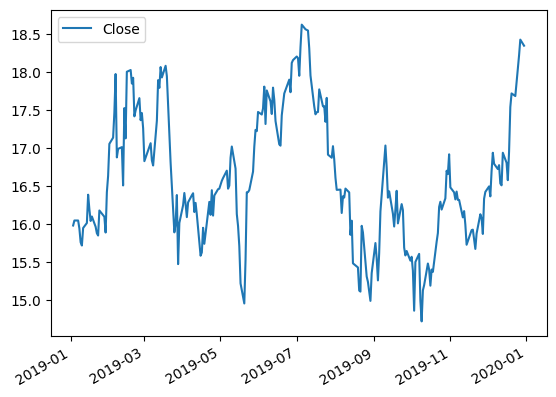

In [14]:
arquivo = 'BBAS3.SA_2021_Teste.json'
arquivodat = 'BBAS3.SA_2019_Treino.json'
dados = obtemdfArquivo(arquivodat)
dados.plot.line(y="Close", use_index=True)

In [15]:

#with open(arquivodat, 'rb') as file:
#    modelo = pickle.load(file)
acuracia ,modelo = ObterAcuraciaModelForestClassifier(arquivodat)
cabecalho = ["Close", "Volume", "Open", "High", "Low"]
resultados = []

for i in range(len(dados)):
    registro = dados[cabecalho].iloc[[i]]
    print("registro -> ", registro)
    #registro = dados[cabecalho].tail(i)
    #print(registro)
    pred = modelo.predict(registro)
    resultados.append(pred)
#print(resultados)
for i in resultados:
    print(i)

registro ->                           Close      Volume       Open       High        Low
2019-01-03 02:00:00  15.984636  29810600.0  15.195272  16.346429  15.159093
registro ->                           Close      Volume      Open       High        Low
2019-01-04 02:00:00  16.050421  17758200.0  15.95175  16.181982  15.737964
registro ->                           Close      Volume       Open       High        Low
2019-01-07 02:00:00  16.050421  17718400.0  15.813612  16.389191  15.760987
registro ->                           Close      Volume       Open       High        Low
2019-01-08 02:00:00  15.945168  18787000.0  16.060285  16.270782  15.843208
registro ->                           Close      Volume       Open       High        Low
2019-01-09 02:00:00  15.764273  29034600.0  15.984636  16.132643  15.402481
registro ->                           Close      Volume       Open       High        Low
2019-01-10 02:00:00  15.721517  33436000.0  15.902412  15.902412  15.616268
registro -> 